# Comparaison des différents modèles entraînés

Ce notebook contient les méthodes et résultats obtenus de la comparaison entre les différents modèles entraînés avec la configuration qui nous avait été fournie. Les modèles comparés sont :
- modèle aléatoire : à chaque pas de temps, une action aléatoire parmi l'ensemble des actions possibles (5 actiosn : lane left (changer de voie pour aller sur celle à gauche de la ligne courante), idle (ne rien modifier), lane right (changer de voie pour aller sur la ligne plus à droite), faster (la voiture augmente sa vitesse), slower (la voiture ralentit sa vitesse))
- DQN avec une couche cachée (de 128 neurones), entraîné avec une architecture et une fonction d'entraînement écrites à la main (disponible dans le dossier ```DQN 1 Layer```)
- DQN avec deux couches cachées (toutes deux de 128 neurones), entraîné également avec des fonctions écrites à la main (disponible dans le dossier ```DQN 2 Layers```)
- DQN entraîné avec stable baselines (notebook d'entraînement dans le dossier ```Stable baselines```)
- Double DQN, défini et entraîné à la main (le notebook d'entraînement est dans le dossier ```Double DQN```)

La comparaison est effectuée sur plusieurs points :
- analyse des courbes et paramètres d'entraînement,
- évaluation statistique sur 50 configurations initiales (les mêmes pour chaque réseau),
- évaluation qualitative des modèles en visualisant leurs différents comportements sur un exemple précis,
- évaluation d'au moins un failure mode par modèle.

La comparaison a lieu avec la même configuration que celle qui a servi à entraîner les modèles, c'est-à-dire celle qui a été fournie initialement.

## Set up

Déclaration de la configuration utilisée et des agents entraînés.

In [96]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from copy import deepcopy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import Counter
from IPython.display import HTML

import highway_env

from stable_baselines3 import DQN

In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


### Configuration utilisée

In [98]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

EVAL_SEEDS = list(range(50))  # for reproducible 

ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

env = make_env(SHARED_CORE_CONFIG)
obs, _ = env.reset()
print("Observation shape :", obs.shape)
print("Action space      :", env.action_space)
print("Flattened obs size:", obs.flatten().shape[0])


Observation shape : (10, 5)
Action space      : Discrete(5)
Flattened obs size: 50


### Agents

#### Random agent

In [99]:
def get_action_random(obs):
    return env.action_space.sample()

#### DQN 1 layer

In [100]:
class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [101]:
CHECKPOINT_PATH = "Checkpoints\dqn_1_layer.pt"

env_tmp = make_env(SHARED_CORE_CONFIG)
obs, _ = env_tmp.reset()
OBS_SIZE  = obs.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n

custom_dqn = QNet(OBS_SIZE, N_ACTIONS).to(device)
custom_dqn.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
custom_dqn.eval()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\arfib\AppData\Local\Temp\ipykernel_39224\3298983749.py:1: SyntaxWarning: invalid escape sequence '\d'
  CHECKPOINT_PATH = "Checkpoints\dqn_1_layer.pt"


QNet(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [102]:
def get_action_1_layer(obs):
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = custom_dqn(state_t)
    return q_values.argmax(dim=1).item()

#### DQN 2 layers

In [103]:
class QNet2Layers(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [104]:
CHECKPOINT_PATH = "Checkpoints\dqn_2_layers.pt"

env_tmp = make_env(SHARED_CORE_CONFIG)
obs, _ = env_tmp.reset()
OBS_SIZE  = obs.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n

custom_dqn_2_layers = QNet2Layers(OBS_SIZE, N_ACTIONS).to(device)
custom_dqn_2_layers.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
custom_dqn_2_layers.eval()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\arfib\AppData\Local\Temp\ipykernel_39224\3756331833.py:1: SyntaxWarning: invalid escape sequence '\d'
  CHECKPOINT_PATH = "Checkpoints\dqn_2_layers.pt"


QNet2Layers(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)

In [105]:
def get_action_2_layers(obs):
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = custom_dqn_2_layers(state_t)
    return q_values.argmax(dim=1).item()

#### Double DQN

In [106]:
class Net(nn.Module):
    def __init__(self, state_dim, action_dim):
        """
        Initialize the network

        : param state_dim: int, size of state space
        : param action_dim: int, size of action space
        """
        super(Net, self).__init__()

        hidden_nodes1 = 512
        hidden_nodes2 = 256
        self.fc1 = nn.Linear(state_dim, hidden_nodes1)
        self.fc2 = nn.Linear(hidden_nodes1, hidden_nodes2)
        self.fc3 = nn.Linear(hidden_nodes2, action_dim)

    def forward(self, state):
        """
        Define the forward pass of the actor

        : param state: ndarray, the state of the environment
        """
        x = state
        # print(x.shape)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        out = self.fc3(x)
        return out

In [107]:
load_path = "Double DQN/0327_16_17/double_dqn.pkl"

loaded_net = Net(state_dim=50, action_dim=5).to(device)
loaded_net.load_state_dict(torch.load(load_path, map_location=device))
loaded_net.eval()

Net(
  (fc1): Linear(in_features=50, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=5, bias=True)
)

In [108]:
def get_action_double_DQN(obs):
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = loaded_net(state_t)
    return q_values.argmax(dim=1).item()

#### DQN stable baselines

In [109]:
sb_dqn = DQN.load("Checkpoints/dqn_stable_baselines")

In [110]:
def get_action_sb(obs):
    action, _states = sb_dqn.predict(obs, deterministic=True)
    return action

## Comparaison des entraînements

- Courbes d'entraînement du DQN à une couche cachée
![DQN 1 couche](DQN%201%20Layer/dqn_training_curves.png)

- Courbes d'entraînement du DQN à deux couches cachées
![DQN 2 couches](DQN%202%20Layers/dqn_2_Layers_training_curves.png)

- Courbes d'entraînement du Double DQN
![Double DQN](Double%20DQN/Training%20and%20Reward.png)

- Courbes d'entraînement du DQN entrapiné avec stable baselines (2 couches cachées)
![Stable baselines](Stable%20baselines/stable_baselines_training_curves.png)


Les courbes d'évolution de la loss pour les DQN à 1 et 2 couches sont similaires : la loss augmente, même si les performances du modèle obtenu sont meilleures au fur et à mesure. Elle est de par ailleurs très bruitée. La loss augmente également pour le double DQN. Ce comportement n'est pas visible pour le DQN entraîné avec stable baselines.

Du point de vue de l'évolution des rewards, la courbe du DQN à une couche entraîné avec des fonctions écrites à la main est exactement ce qu'on attend à la fin d'un bon entraînement : la valeur du reward par épisode a atteint un plateau (ce qui pousse à dire qu'il ne servirait à rien d'entraîner plus), et les valeurs ne sont plus bruitées. Pour le DQN à deux couches cachées entraîné avec des fonctions écrites à la main, le reward par épisode est toujours très bruité à la fin de l'entraînement, et les valeurs de validation ont baissé par rapport à un stade de l'entraînement antérieur. 

Pour le DQN entraîné avec stable baselines, le reward de validation est bien plus élevé que le reward de train et semble toujours augmenter, ce qui pousse à penser qu'entraîner un peu plus aurait pu améliorer les performances du modèle.

Un DQN à une seule couche cachée semble suffire au vu des courbes d'entraînement seules : son comportement paraît stable à la fin de l'entraînement, et le reward moyen obtenu est proche de 20 ce qui est supérieur aux modèle avec deux couches cachées (entraîné "à la main" et avec stable baselines), et au double DQN.

## Evaluation statistique

On fait une comparaison statistiques des différents modèles en initialisant 50 épisodes avec des seeds prédéfinies (de 0 à 49). Les métriques utilisées sont :
- la moyenne et l'écart type du reward obtenu
- moyenne et écart type de la longueur de l'épisode
- moyenne et écrat type de la distance parcourue au cours de l'épisode (on a accès à la vitesse instantanée de la voiture grâce à l'environnement)
- pourcentage d'épisodes terminés sans collision
- distribution globale des actions prises par les différents modèles

In [111]:
def eval_agent(get_action, CONFIG, EVAL_SEEDS):
    """
    Monte Carlo evaluation using fixed seeds.
    """
    n_sim = len(EVAL_SEEDS)

    env = make_env(CONFIG)
    env_copy = deepcopy(env)

    episode_rewards = np.zeros(n_sim)
    episode_lengths = np.zeros(n_sim)
    episode_distances = np.zeros(n_sim)
    episode_collisions = np.zeros(n_sim, dtype=bool)
    episode_actions = []

    for i, seed in enumerate(EVAL_SEEDS):
        print(f"Simulating episode {i} with seed {seed}")

        state, _ = env_copy.reset(seed=seed)
        reward_sum = 0
        length = 0
        distance = 0
        actions = []
        done = False
        while not done: 
            action = get_action(state)
            actions.append(action)
            state, reward, terminated, truncated, _ = env_copy.step(action)
            reward_sum += reward
            length+=1
            dt = 1 / env_copy.unwrapped.config["simulation_frequency"]
            speed = env_copy.unwrapped.vehicle.speed
            distance += speed * dt
            done = terminated or truncated
        if terminated:
            episode_collisions[i] = True
        episode_rewards[i] = reward_sum
        episode_lengths[i] = length
        episode_distances[i] = distance
        episode_actions.append(actions)
    return episode_rewards, episode_lengths, episode_distances, episode_collisions, episode_actions

In [28]:
EVAL_SEEDS = list(range(50))
eval_double_dqn=eval_agent(get_action_double_DQN, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_random = eval_agent(get_action_random, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_custom_1_layer = eval_agent(get_action_1_layer, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_custom_2_layers = eval_agent(get_action_2_layers, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_sb = eval_agent(get_action_sb, SHARED_CORE_CONFIG, EVAL_SEEDS)

Simulating episode 0 with seed 0
Simulating episode 1 with seed 1
Simulating episode 2 with seed 2
Simulating episode 3 with seed 3
Simulating episode 4 with seed 4
Simulating episode 5 with seed 5
Simulating episode 6 with seed 6
Simulating episode 7 with seed 7
Simulating episode 8 with seed 8
Simulating episode 9 with seed 9
Simulating episode 10 with seed 10
Simulating episode 11 with seed 11
Simulating episode 12 with seed 12
Simulating episode 13 with seed 13
Simulating episode 14 with seed 14
Simulating episode 15 with seed 15
Simulating episode 16 with seed 16
Simulating episode 17 with seed 17
Simulating episode 18 with seed 18
Simulating episode 19 with seed 19
Simulating episode 20 with seed 20
Simulating episode 21 with seed 21
Simulating episode 22 with seed 22
Simulating episode 23 with seed 23
Simulating episode 24 with seed 24
Simulating episode 25 with seed 25
Simulating episode 26 with seed 26
Simulating episode 27 with seed 27
Simulating episode 28 with seed 28
Simul

In [ ]:
import pandas as pd

def results_to_row(results, agent_name):
    rewards, lengths, distances, collisions, actions = results
    
    return {"agent": agent_name,"rewards": list(rewards),"lengths": list(lengths),"distances": list(distances),"collisions": list(collisions),"actions": actions}

df_all = pd.DataFrame([
    results_to_row(eval_double_dqn, "double_dqn"),
    results_to_row(eval_random, "random"),
    results_to_row(eval_custom_1_layer, "custom_1_layer"),
    results_to_row(eval_custom_2_layers, "custom_2_layers"),
    results_to_row(eval_sb, "stable_baselines")
])

df_all.to_pickle("results.pkl")

In [112]:
def compute_metrics(eval_output):
    rewards, lengths, distances, collisions, actions = eval_output

    metrics = {
        "mean_reward": float(rewards.mean()),
        "std_reward": float(rewards.std()),
        "mean_episode_length": float(lengths.mean()),
        "std_episode_length": float(lengths.std()),
        "mean_distance": float(distances.mean()),
        "std_distance": float(distances.std()),
        "success_rate": float(100 * (~collisions).mean()),
        "collision_rate": float(100 * collisions.mean()),
    }

    all_actions = np.concatenate(actions) if len(actions) > 0 else np.array([], dtype=int)
    counts = np.bincount(all_actions, minlength=N_ACTIONS) if all_actions.size > 0 else np.zeros(N_ACTIONS, dtype=int)
    total_actions = counts.sum()

    for a in range(N_ACTIONS):
        metrics[f"action_count_{a}"] = int(counts[a])
        metrics[f"action_pct_{a}"] = float(100 * counts[a] / total_actions) if total_actions > 0 else 0.0

    return metrics

def print_eval_metrics(eval_output, label="Agent"):
    metrics = compute_metrics(eval_output)

    print(f"Evaluation Results for network {label}")
    print(f"Reward: mean = {metrics['mean_reward']:.3f}, std = {metrics['std_reward']:.3f}")
    print(f"Length: mean = {metrics['mean_episode_length']:.2f}, std = {metrics['std_episode_length']:.2f}")
    print(f"Distance: mean = {metrics['mean_distance']:.2f}, std = {metrics['std_distance']:.2f}")
    print(f"No collision: {metrics['success_rate']:.1f}%")
    print(f"Collision: {metrics['collision_rate']:.1f}%")

    print("Action distribution:")
    for a in range(N_ACTIONS):
        action_name = ACTION_LABELS.get(a, str(a))
        print(f"  {action_name}: {metrics[f'action_count_{a}']} ({metrics[f'action_pct_{a}']:.1f}%)")

    print("\n")

    return metrics


def evaluate_dataframe(df):
    all_metrics = []

    for _, row in df.iterrows():
        eval_output = (
            np.array(row["rewards"]),
            np.array(row["lengths"]),
            np.array(row["distances"]),
            np.array(row["collisions"]),
            row["actions"]
        )

        metrics = print_eval_metrics(eval_output, label=row["agent"])

        metrics["agent"] = row["agent"]
        all_metrics.append(metrics)

    return pd.DataFrame(all_metrics)

In [113]:
df_all = pd.read_pickle("results.pkl")

df_metrics=evaluate_dataframe(df_all)

Evaluation Results for network double_dqn
Reward: mean = 19.286, std = 4.903
Length: mean = 27.48, std = 6.85
Distance: mean = 38.42, std = 9.32
No collision: 86.0%
Collision: 14.0%
Action distribution:
  LANE_LEFT: 141 (10.3%)
  IDLE: 240 (17.5%)
  LANE_RIGHT: 407 (29.6%)
  FASTER: 113 (8.2%)
  SLOWER: 473 (34.4%)


Evaluation Results for network random
Reward: mean = 9.263, std = 7.331
Length: mean = 12.36, std = 9.30
Distance: mean = 19.64, std = 14.51
No collision: 14.0%
Collision: 86.0%
Action distribution:
  LANE_LEFT: 138 (22.3%)
  IDLE: 135 (21.8%)
  LANE_RIGHT: 105 (17.0%)
  FASTER: 123 (19.9%)
  SLOWER: 117 (18.9%)


Evaluation Results for network custom_1_layer
Reward: mean = 20.506, std = 0.165
Length: mean = 30.00, std = 0.00
Distance: mean = 40.22, std = 0.50
No collision: 100.0%
Collision: 0.0%
Action distribution:
  LANE_LEFT: 144 (9.6%)
  IDLE: 157 (10.5%)
  LANE_RIGHT: 385 (25.7%)
  FASTER: 16 (1.1%)
  SLOWER: 798 (53.2%)


Evaluation Results for network custom_2_laye

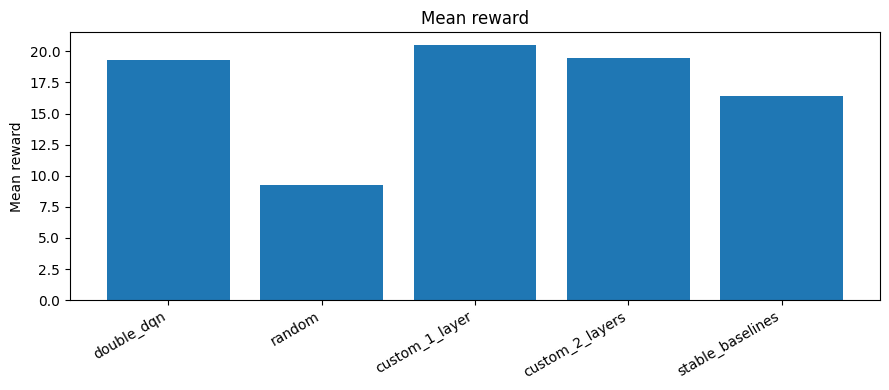

In [114]:
plt.figure(figsize=(9, 4))
plt.bar(df_metrics["agent"], df_metrics["mean_reward"])
plt.ylabel("Mean reward")
plt.title("Mean reward")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

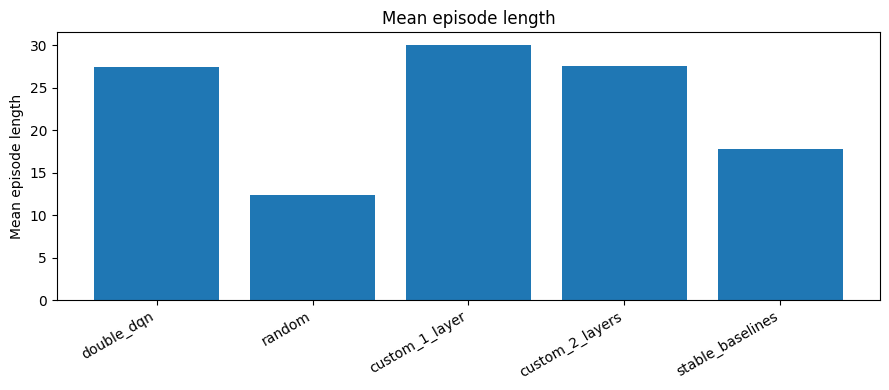

In [115]:
plt.figure(figsize=(9, 4))
plt.bar(df_metrics["agent"], df_metrics["mean_episode_length"])
plt.ylabel("Mean episode length")
plt.title("Mean episode length")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

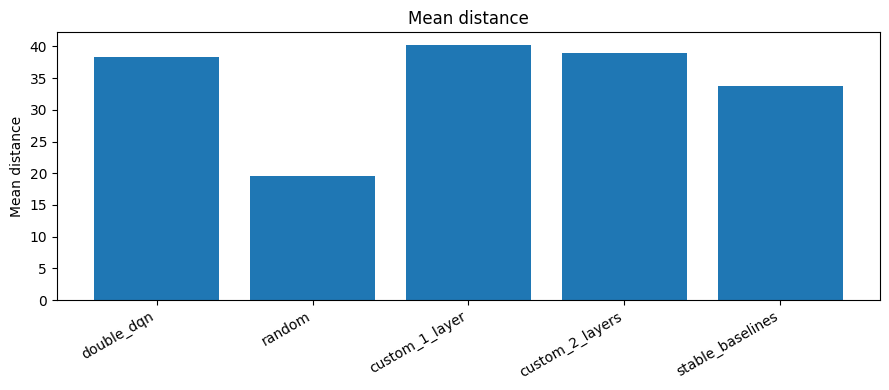

In [116]:
df_plot = df_metrics

plt.figure(figsize=(9, 4))
plt.bar(df_plot["agent"], df_plot["mean_distance"])
plt.ylabel("Mean distance")
plt.title("Mean distance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

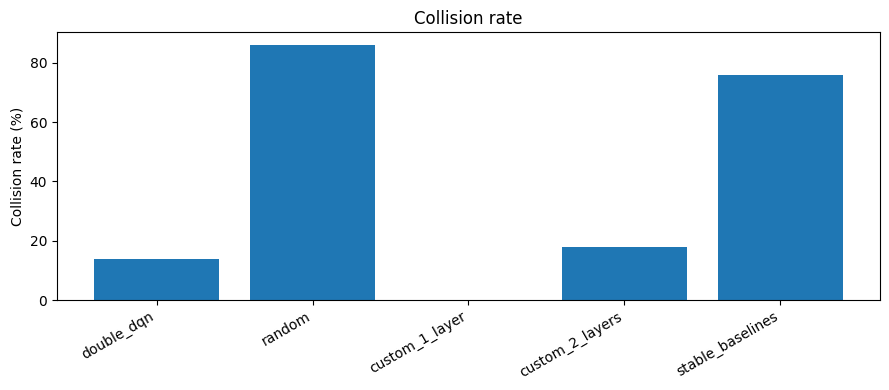

In [117]:
plt.figure(figsize=(9, 4))
plt.bar(df_metrics["agent"], df_metrics["collision_rate"])
plt.ylabel("Collision rate (%)")
plt.title("Collision rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

En terme de rewards, le Custom DQN à 1 couche est le plus performant et le plus stable : il a un reward moyen élevé, et un écart-type très faible. Le Custome DQN à deux couches cachées et le Double DQN ont des performances très proches en terme de reward moyen, mais avec beaucoup plus de variations (écart type plus élevé). Le modèle Stable Baselines est lui moins performant que les autres (un reward moyen proche de 16 VS proche de 20 pour le DQN à une couche cachée). 

Des conclusions similaires peuvent être tirées pour l'analyse de la longueur des épisodes. 

En termes de collisions à l'issue d'un épisode, le modèle obtenu avec stable baselines est rtès risqué, puisqu'il conduit à une collision dans 76% des cas simulés. Au contraire, le DQN à une couche cachée ne conduit jamais à une collision (en tout cas au cours des 30 pas de temps simulés d'après la config). 

In [118]:
def plot_action_distribution(df, n_actions, action_labels):
    """
    Plot action distribution per agent from df_all.
    """

    x = np.arange(n_actions)
    width = 0.8 / max(len(df), 1)

    plt.figure(figsize=(12, 5))

    for i, (_, row) in enumerate(df.iterrows()):
        all_actions = []
        
        for episode in row["actions"]:
            for a in episode:
                if isinstance(a, np.ndarray):
                    all_actions.append(int(a.item()))
                else:
                    all_actions.append(int(a))

        counter = Counter(all_actions)
        counts = [counter.get(a, 0) for a in range(n_actions)]

        plt.bar(
            x + i * width - (len(df) - 1) * width / 2,
            counts,
            width=width,
            label=row["agent"],
            alpha=0.8,
        )

    plt.xticks(x, [action_labels[a] for a in range(n_actions)], rotation=15)
    plt.ylabel("Action count across all eval episodes")
    plt.title("Action distribution comparison")
    plt.legend()
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()

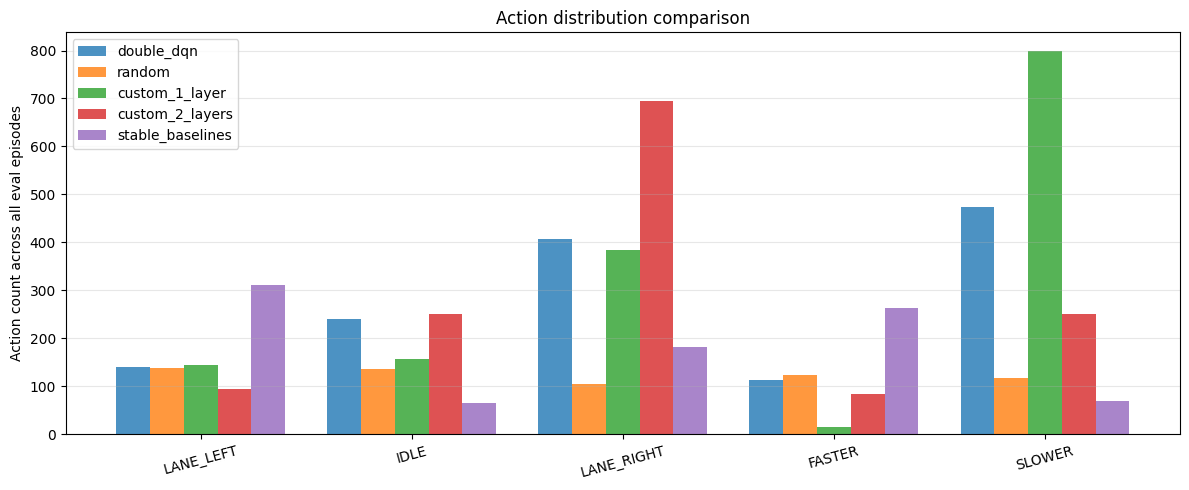

In [119]:
plot_action_distribution(df_all, N_ACTIONS, action_labels=ACTION_LABELS)

Le modèle DQN à une couche cachée semble être très prudent : il ralentit très souvent et accélère très rarement. Il a également tendance à demander un changement de ligne vers la droite. Au contraire, le modèle entraîné avec stable baselines a plutôt tendance à demander un changement de voie vers la gauche et à accélérer plutôt que ralentir. 

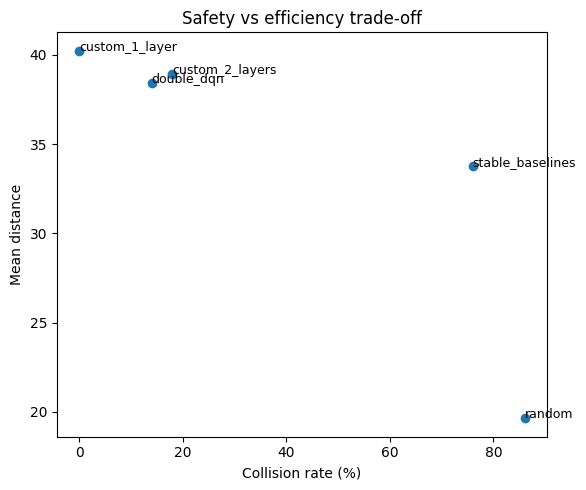

In [120]:
plt.figure(figsize=(6, 5))
plt.scatter(df_metrics["collision_rate"], df_metrics["mean_distance"])

for _, row in df_metrics.iterrows():
    plt.text(row["collision_rate"], row["mean_distance"], row["agent"], fontsize=9)

plt.xlabel("Collision rate (%)")
plt.ylabel("Mean distance")
plt.title("Safety vs efficiency trade-off")
plt.tight_layout()
plt.show()

## Evaluation qualitative des comportements

Dans cette partie, on évalue sur un run (on choisit la seed de l'épisode) l'évolution du reward pour tous les modèles disponibles, ainsi que la distribution des actions et l'évolution de la vitesse. On peut également visualiser le déroulé de l'épisode pour chacun des modèles.

In [121]:
def compare_agents(get_actions, agent_names, CONFIG, seed, n_actions, action_labels=None):

    episodes_data = []

    for get_action in get_actions:
        env = make_env(CONFIG)
        state, _ = env.reset(seed=seed)

        rewards = []
        actions = []
        speeds = []

        done = False
        while not done:
            action = get_action(state)
            actions.append(action)

            state, reward, terminated, truncated, _ = env.step(action)

            rewards.append(reward)
            speeds.append(env.unwrapped.vehicle.speed)

            done = terminated or truncated

        episodes_data.append({
            "rewards": np.array(rewards),
            "actions": np.array(actions),
            "speeds": np.array(speeds),
        })

    n_agents = len(episodes_data)
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    for i, data in enumerate(episodes_data):
        ax.plot(np.cumsum(data["rewards"]), lw=2, color=colors[i], label=agent_names[i])

    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Reward")
    ax.set_title("Cumulative reward")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    for i, data in enumerate(episodes_data):
        ax.plot(data["speeds"], lw=2, color=colors[i], label=agent_names[i])

    ax.set_xlabel("Step")
    ax.set_ylabel("Speed")
    ax.set_title("Speed over time")
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[2]
    x = np.arange(n_actions)
    width = 0.8 / n_agents

    if action_labels is None:
        labels = [str(i) for i in range(n_actions)]
    else:
        labels = [action_labels.get(i, str(i)) for i in range(n_actions)]

    for i, data in enumerate(episodes_data):
        counts = np.bincount(data["actions"], minlength=n_actions)

        ax.bar(x+i*width-(n_agents-1)*width/2, counts, width, label=agent_names[i], alpha=0.8, color=colors[i])

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel("Count")
    ax.set_title("Action distribution")
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

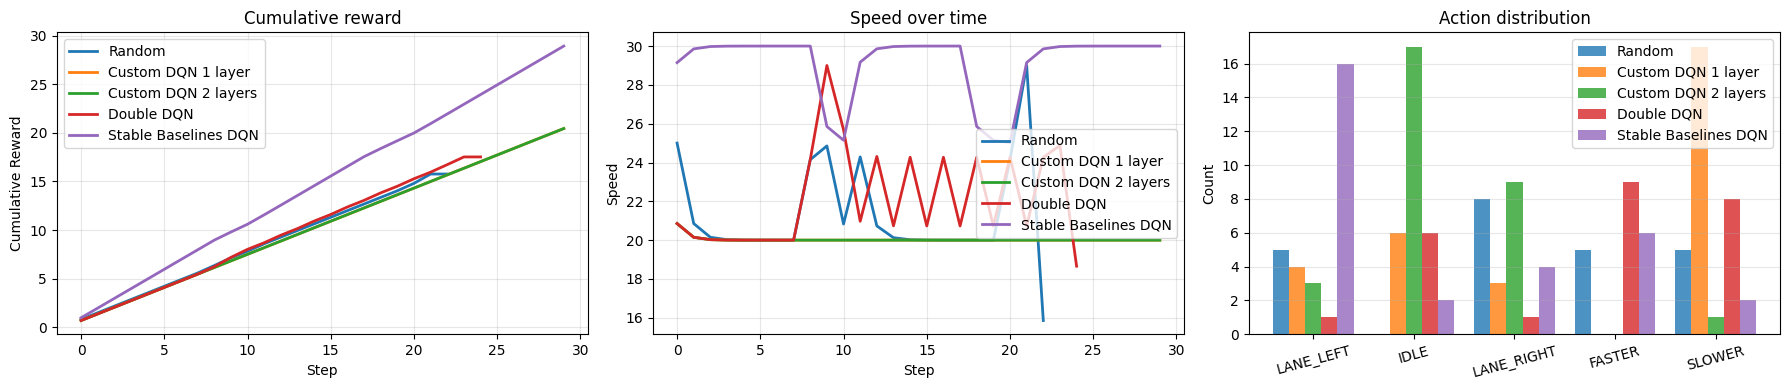

In [122]:
compare_agents(
    get_actions=[get_action_random, get_action_1_layer, get_action_2_layers, get_action_double_DQN, get_action_sb],
    agent_names=["Random", "Custom DQN 1 layer", "Custom DQN 2 layers", "Double DQN", "Stable Baselines DQN"],
    CONFIG=SHARED_CORE_CONFIG,
    seed=1,
    n_actions=N_ACTIONS,
    action_labels=ACTION_LABELS
)

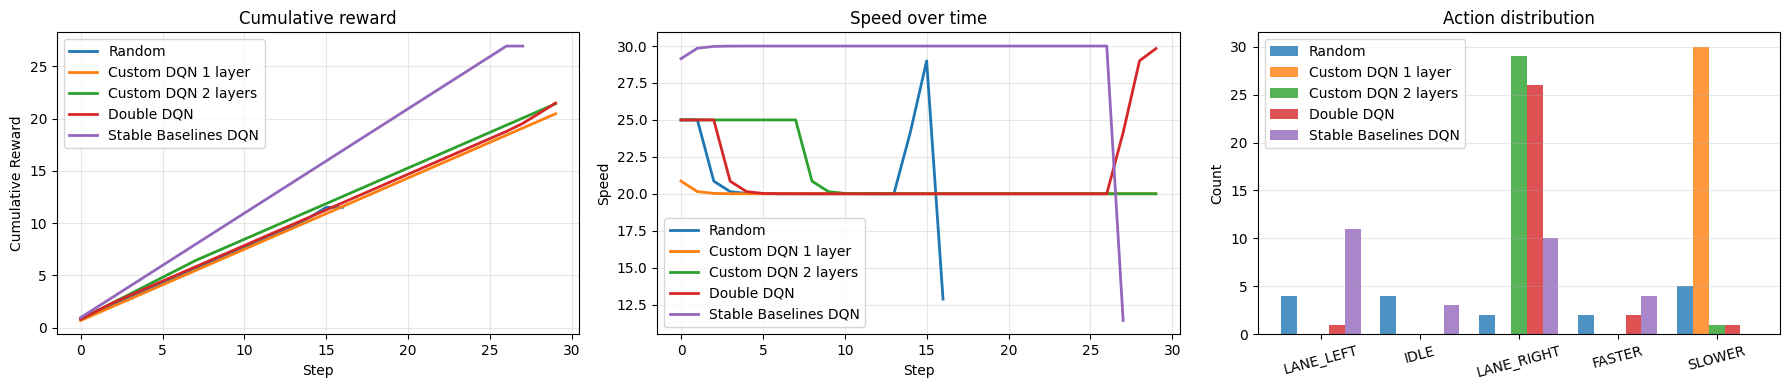

In [123]:
compare_agents(
    get_actions=[get_action_random, get_action_1_layer, get_action_2_layers, get_action_double_DQN, get_action_sb],
    agent_names=["Random", "Custom DQN 1 layer", "Custom DQN 2 layers", "Double DQN", "Stable Baselines DQN"],
    CONFIG=SHARED_CORE_CONFIG,
    seed=3,
    n_actions=N_ACTIONS,
    action_labels=ACTION_LABELS
)

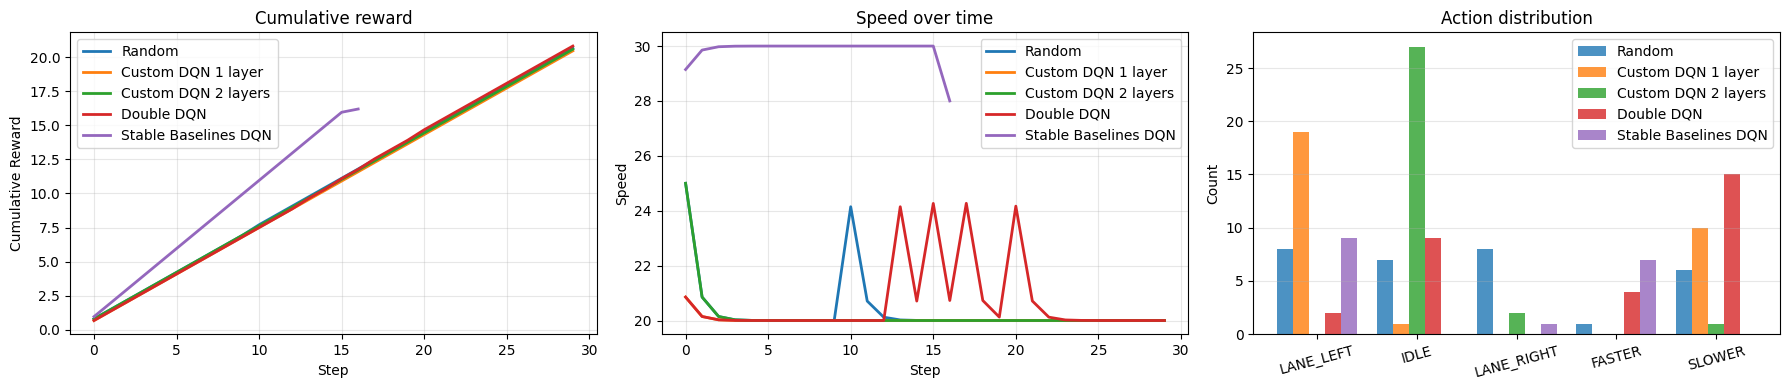

In [124]:
compare_agents(
    get_actions=[get_action_random, get_action_1_layer, get_action_2_layers, get_action_double_DQN, get_action_sb],
    agent_names=["Random", "Custom DQN 1 layer", "Custom DQN 2 layers", "Double DQN", "Stable Baselines DQN"],
    CONFIG=SHARED_CORE_CONFIG,
    seed=4,
    n_actions=N_ACTIONS,
    action_labels=ACTION_LABELS
)

Cette simulation illustre exactement les comportements qui ressortaient dans l'analyse des métriques et de la répartition des actions. 

Le modèle entraîné avec stable baselines est très peu prudent et a une vitesse généralement très élevée, ce qui le conduit à un crash dans un grand nombre de situations (2 des 3 exemples simulés). Cependant, dans les cas où il ne crash pas, il obtient un haut reward dû à sa grande distance parcourue.

Au contraire, le DQN avec une couche cachée est très prudent : il ralentit très vite, et cela lui permet de terminer tous les épisodes simlés sans crash.

On peut visualiser le comportement des différents agents dans les cellules ci-dessous :

In [125]:
import os


def run_episode(get_action, config, seed, agent_name, video_folder=None):

    env = make_env(config, render_mode="rgb_array")

    if video_folder is not None:
        os.makedirs(video_folder, exist_ok=True)
        env=RecordVideo(env, video_folder, episode_trigger=lambda episode_id: True, name_prefix=f"{agent_name}-seed-{seed}")

    obs, _ = env.reset(seed=seed)

    frames, actions, rewards = [], [], []
    done = False

    while not done:
        action = get_action(obs)
        obs, r, terminated, truncated, _ = env.step(action)
        frame = env.render()
        if frame is not None:
            frames.append(frame)
            actions.append(int(action))
            rewards.append(r)
        done = terminated or truncated

    env.close()

    return frames, actions, rewards, terminated


In [126]:
def make_animation(frames, actions, rewards, title, fps=10):
    """Return an HTML5 video animation."""
    if not frames:
        raise ValueError(f"No frames to animate for '{title}'. Re-run cell 5.")

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    img_obj = ax.imshow(frames[0])

    cumulative = np.cumsum(rewards)
    title_obj = ax.set_title("", fontsize=11)

    def update(i):
        img_obj.set_data(frames[i])
        action_label = ACTION_LABELS.get(actions[i], str(actions[i])) if i < len(actions) else "-"
        title_obj.set_text(
            f"{title}   |   step {i+1}/{len(frames)}   "
            f"|   action: {action_label}   "
            f"|   step_r: {rewards[i]:.3f}   "
            f"|   cum_r: {cumulative[i]:.3f}"
        )
        return img_obj, title_obj

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=1000 // fps, blit=True
    )
    plt.close(fig)
    return ani


In [127]:
frames, actions, rewards, crashed = run_episode(get_action_sb, SHARED_CORE_CONFIG, seed=4, agent_name="stable_baselines", video_folder="videos")

ani_after = make_animation(
    frames, actions, rewards,
    title="stable baselines", fps=5
)
HTML(ani_after.to_jshtml())

c:\Users\arfib\anaconda3\envs\RL_env\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\arfib\Documents\CentraleSupelec\cours 3A\RL Apprentissage par Renforcement\projet\Reinforcement_learning_highway\core_task\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
c:\Users\arfib\anaconda3\envs\RL_env\Lib\site-packages\gymnasium\wrappers\rendering.py:434: UserWarning: WARN: Unable to save last video! Did you call close()?
  logger.warn("Unable to save last video! Did you call close()?")


In [128]:
frames, actions, rewards, crashed = run_episode(get_action_1_layer, SHARED_CORE_CONFIG, seed=4, agent_name="custom_dqn_1_layer", video_folder="videos")

ani_after = make_animation(
    frames, actions, rewards,
    title="DQN 1 layer", fps=5
)
HTML(ani_after.to_jshtml())

c:\Users\arfib\anaconda3\envs\RL_env\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\arfib\Documents\CentraleSupelec\cours 3A\RL Apprentissage par Renforcement\projet\Reinforcement_learning_highway\core_task\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [ ]:
frames, actions, rewards, crashed = run_episode(get_action_sb, SHARED_CORE_CONFIG, seed=, agent_name="stable_baselines", video_folder="videos")

ani_after = make_animation(
    frames, actions, rewards,
    title="stable baselines", fps=5
)
HTML(ani_after.to_jshtml())

c:\Users\arfib\anaconda3\envs\RL_env\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\arfib\Documents\CentraleSupelec\cours 3A\RL Apprentissage par Renforcement\projet\Reinforcement_learning_highway\core_task\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


## Failure modes

Pour le modèle entraîné avec stable baselines, le failure mode principal est lié à sa tendance à accélérer coute que coute : au lieu de ralentir en cas de danger imminent, l'agent va souvent crash dans la voiture en face de lui (comme c'est le cas dans la vidéo de l'épisode généré par la seed 2 par exemple). L'agent a également tendance à effectuer des changements de voies inutiles (comme c'est le cas à la fin de la vidéo de l'épisode généré par la seed 1 par exemple).

Au contraire, le modèle entraîné par nos soins est beaucoup plus prudent. Il donne lieu lui aussi à des changements de voie intempestifs, mais pas à des crashs (on note un taux de crash de 0% sur les seeds étudiées) ce qui en fait un failure mode sans grande importance. Néanmoins, lorsqu'on augmente la densité de voitures autour de l'agent, cela donne lieu à plus de crash comme en témoigne la cellule ci dessous.

In [129]:
DENSE_BASELINE_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
}

In [130]:
EVAL_SEEDS = list(range(50))
# eval_double_dqn=eval_agent(get_action_double_DQN, SHARED_CORE_CONFIG, EVAL_SEEDS)
eval_random_dense = eval_agent(get_action_random, DENSE_BASELINE_CONFIG, EVAL_SEEDS)
eval_custom_1_layer_dense = eval_agent(get_action_1_layer, DENSE_BASELINE_CONFIG, EVAL_SEEDS)
# eval_custom_2_layers = eval_agent(get_action_2_layers, DENSE_BASELINE_CONFIG, EVAL_SEEDS)
eval_sb_dense = eval_agent(get_action_sb, DENSE_BASELINE_CONFIG, EVAL_SEEDS)

Simulating episode 0 with seed 0
Simulating episode 1 with seed 1
Simulating episode 2 with seed 2
Simulating episode 3 with seed 3
Simulating episode 4 with seed 4
Simulating episode 5 with seed 5
Simulating episode 6 with seed 6
Simulating episode 7 with seed 7
Simulating episode 8 with seed 8
Simulating episode 9 with seed 9
Simulating episode 10 with seed 10
Simulating episode 11 with seed 11
Simulating episode 12 with seed 12
Simulating episode 13 with seed 13
Simulating episode 14 with seed 14
Simulating episode 15 with seed 15
Simulating episode 16 with seed 16
Simulating episode 17 with seed 17
Simulating episode 18 with seed 18
Simulating episode 19 with seed 19
Simulating episode 20 with seed 20
Simulating episode 21 with seed 21
Simulating episode 22 with seed 22
Simulating episode 23 with seed 23
Simulating episode 24 with seed 24
Simulating episode 25 with seed 25
Simulating episode 26 with seed 26
Simulating episode 27 with seed 27
Simulating episode 28 with seed 28
Simul

In [131]:
df_all_dense = pd.DataFrame([
    results_to_row(eval_random_dense, "random"),
    results_to_row(eval_custom_1_layer_dense, "custom_1_layer"),
    results_to_row(eval_sb_dense, "stable_baselines")
])

df_all_dense.to_pickle("results_dense.pkl")

df_metrics_dense=evaluate_dataframe(df_all_dense)

Evaluation Results for network random
Reward: mean = 2.760, std = 2.038
Length: mean = 4.48, std = 2.77
Distance: mean = 6.67, std = 4.08
No collision: 0.0%
Collision: 100.0%
Action distribution:
  LANE_LEFT: 45 (20.1%)
  IDLE: 51 (22.8%)
  LANE_RIGHT: 33 (14.7%)
  FASTER: 45 (20.1%)
  SLOWER: 50 (22.3%)


Evaluation Results for network custom_1_layer
Reward: mean = 8.023, std = 6.371
Length: mean = 12.54, std = 9.13
Distance: mean = 16.60, std = 12.24
No collision: 12.0%
Collision: 88.0%
Action distribution:
  LANE_LEFT: 120 (19.1%)
  IDLE: 11 (1.8%)
  LANE_RIGHT: 65 (10.4%)
  FASTER: 0 (0.0%)
  SLOWER: 431 (68.7%)


Evaluation Results for network stable_baselines
Reward: mean = 3.992, std = 2.251
Length: mean = 5.20, std = 2.24
Distance: mean = 9.21, std = 4.57
No collision: 0.0%
Collision: 100.0%
Action distribution:
  LANE_LEFT: 84 (32.3%)
  IDLE: 24 (9.2%)
  LANE_RIGHT: 51 (19.6%)
  FASTER: 80 (30.8%)
  SLOWER: 21 (8.1%)




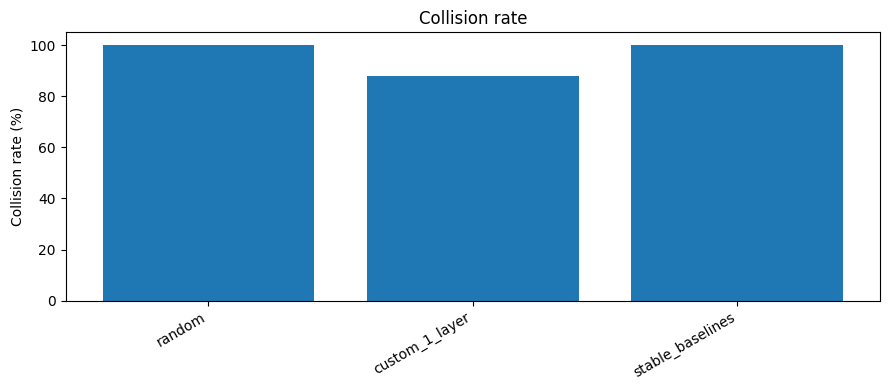

In [132]:
plt.figure(figsize=(9, 4))
plt.bar(df_metrics_dense["agent"], df_metrics_dense["collision_rate"])
plt.ylabel("Collision rate (%)")
plt.title("Collision rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

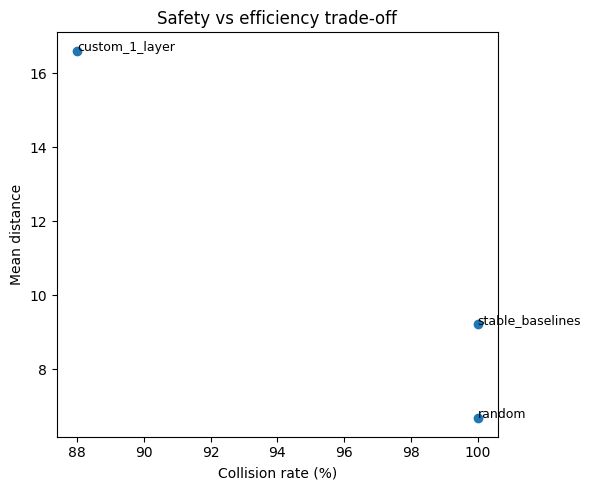

In [134]:
plt.figure(figsize=(6, 5))
plt.scatter(df_metrics_dense["collision_rate"], df_metrics_dense["mean_distance"])

for _, row in df_metrics_dense.iterrows():
    plt.text(row["collision_rate"], row["mean_distance"], row["agent"], fontsize=9)

plt.xlabel("Collision rate (%)")
plt.ylabel("Mean distance")
plt.title("Safety vs efficiency trade-off")
plt.tight_layout()
plt.show()

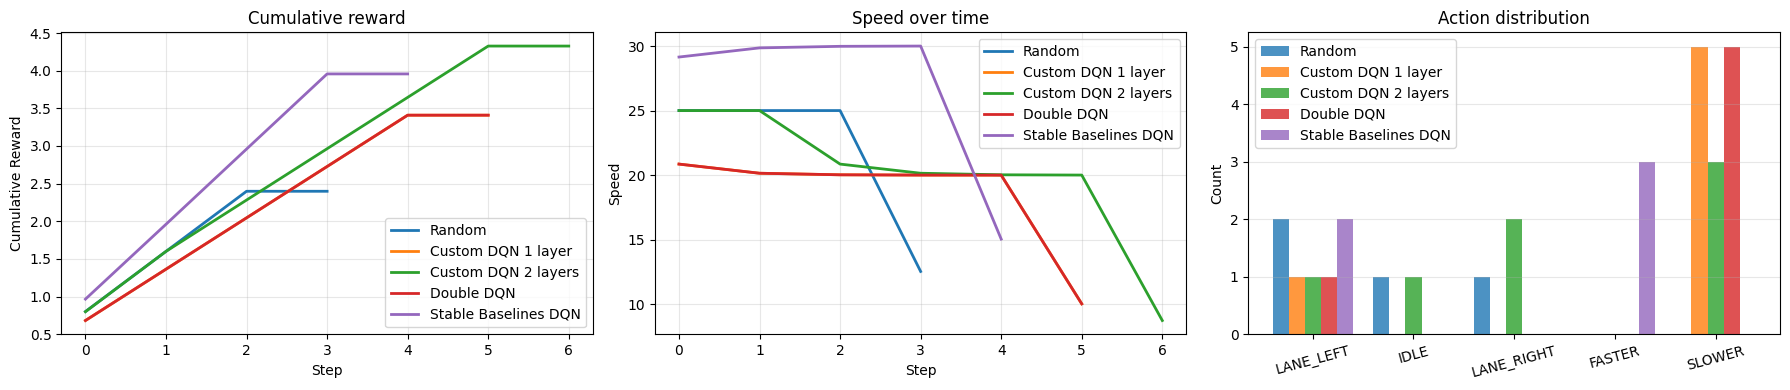

In [135]:
compare_agents(
    get_actions=[get_action_random, get_action_1_layer, get_action_2_layers, get_action_double_DQN, get_action_sb],
    agent_names=["Random", "Custom DQN 1 layer", "Custom DQN 2 layers", "Double DQN", "Stable Baselines DQN"],
    CONFIG=DENSE_BASELINE_CONFIG,
    seed=4,
    n_actions=N_ACTIONS,
    action_labels=ACTION_LABELS
)

In [ ]:
frames, actions, rewards, crashed = run_episode(get_action_1_layer, DENSE_BASELINE_CONFIG, seed=4, agent_name="custom_dqn_1_layer_dense", video_folder="videos")

ani_after = make_animation(
    frames, actions, rewards,
    title="DQN 1 layer", fps=5
)
HTML(ani_after.to_jshtml())

c:\Users\arfib\anaconda3\envs\RL_env\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\arfib\Documents\CentraleSupelec\cours 3A\RL Apprentissage par Renforcement\projet\Reinforcement_learning_highway\core_task\videos_dense folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Cette fois ci, l'agent décide de changer de voie alors qu'il y a une voiture sur la voie de destination : il reste prudent vis à vis de la voiture devant lui et tente de changer de voie pour garder une certaine distance de sécurité, mais cela au détriment de la sécurité sur les côtés.